In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q scikit-learn scikit-image opencv-python matplotlib seaborn joblib
print("✅ Libraries ready!")

✅ Libraries ready!


In [3]:
from google.colab import files
import zipfile, os, shutil

print("📁 Click 'Choose Files' and select your ZIP file from D: drive")
uploaded = files.upload()

📁 Click 'Choose Files' and select your ZIP file from D: drive


KeyboardInterrupt: 

In [4]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted!


In [5]:
import zipfile, os

# Find your zip file
zip_path = '/content/drive/MyDrive/animal dataset 1....zip'

print("📦 Extracting...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/drive/MyDrive/new_animal_classifier/dataset')
print("✅ Extracted!")

# Check folders
path = '/content/drive/MyDrive/new_animal_classifier/dataset'
for folder in os.listdir(path):
    count = len(os.listdir(os.path.join(path, folder)))
    print(f"  🐾 {folder}: {count} images")


📦 Extracting...
✅ Extracted!
  🐾 cat: 111 images
  🐾 cow: 101 images
  🐾 dog: 105 images
  🐾 lamb: 107 images
  🐾 zebra: 108 images


In [6]:
import os, shutil, random

CLASSES = ['cat', 'cow', 'dog', 'lamb', 'zebra']
src_base  = '/content/drive/MyDrive/new_animal_classifier/dataset'
dest_base = '/content/drive/MyDrive/new_animal_classifier/selected'

random.seed(42)

for animal in CLASSES:
    src_folder  = os.path.join(src_base, animal)
    dst_folder  = os.path.join(dest_base, animal)
    os.makedirs(dst_folder, exist_ok=True)

    images = [f for f in os.listdir(src_folder)
              if f.lower().endswith(('.jpg','.jpeg','.png'))]
    random.shuffle(images)
    selected = images[:100]

    for img in selected:
        shutil.copy(os.path.join(src_folder, img),
                    os.path.join(dst_folder, img))
    print(f"✅ {animal}: 100 images selected!")

print("\n🎉 All 5 classes ready!")

✅ cat: 100 images selected!
✅ cow: 100 images selected!
✅ dog: 100 images selected!
✅ lamb: 100 images selected!
✅ zebra: 100 images selected!

🎉 All 5 classes ready!


In [7]:
import os, shutil, random

CLASSES = ['cat', 'cow', 'dog', 'lamb', 'zebra']
src_base   = '/content/drive/MyDrive/new_animal_classifier/selected'
train_base = '/content/drive/MyDrive/new_animal_classifier/train'
test_base  = '/content/drive/MyDrive/new_animal_classifier/test'

random.seed(42)

for animal in CLASSES:
    src   = os.path.join(src_base, animal)
    train = os.path.join(train_base, animal)
    test  = os.path.join(test_base, animal)

    os.makedirs(train, exist_ok=True)
    os.makedirs(test, exist_ok=True)

    images = os.listdir(src)
    random.shuffle(images)

    for img in images[:80]:
        shutil.copy(os.path.join(src, img), os.path.join(train, img))
    for img in images[80:100]:
        shutil.copy(os.path.join(src, img), os.path.join(test, img))

    print(f"✅ {animal}: 80 train | 20 test")

print("\n🎉 Dataset split complete!")

✅ cat: 80 train | 20 test
✅ cow: 80 train | 20 test
✅ dog: 80 train | 20 test
✅ lamb: 80 train | 20 test
✅ zebra: 80 train | 20 test

🎉 Dataset split complete!


In [8]:
import numpy as np
import os
import cv2
import joblib
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

CLASSES = ['cat', 'cow', 'dog', 'lamb', 'zebra']

print("⚙️  Loading ResNet50...")
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
print("✅ ResNet50 ready!")

def load_images(base_path):
    X, y = [], []
    for label, cls in enumerate(CLASSES):
        folder = os.path.join(base_path, cls)
        count = 0
        for fname in os.listdir(folder):
            path = os.path.join(folder, fname)
            img  = cv2.imread(path)
            if img is None: continue
            img = cv2.resize(img, (224, 224))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            X.append(img)
            y.append(label)
            count += 1
        print(f"  ✅ {cls}: {count} images loaded")
    return np.array(X), np.array(y)

def extract_cnn_features(images):
    imgs = preprocess_input(images.astype('float32'))
    return base_model.predict(imgs, batch_size=32, verbose=1)

print("\n📂 Loading training images...")
X_train_img, y_train = load_images('/content/drive/MyDrive/new_animal_classifier/train')

print("\n📂 Loading test images...")
X_test_img, y_test = load_images('/content/drive/MyDrive/new_animal_classifier/test')

print("\n⚙️  Extracting CNN features...")
X_train_feat = extract_cnn_features(X_train_img)
X_test_feat  = extract_cnn_features(X_test_img)

joblib.dump((X_train_feat, y_train, X_test_feat, y_test),
            '/content/drive/MyDrive/new_animal_classifier/cnn_features.pkl')
print(f"\n✅ Features saved!")
print(f"   Train shape: {X_train_feat.shape}")
print(f"   Test shape:  {X_test_feat.shape}")

⚙️  Loading ResNet50...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ ResNet50 ready!

📂 Loading training images...
  ✅ cat: 80 images loaded
  ✅ cow: 80 images loaded
  ✅ dog: 80 images loaded
  ✅ lamb: 80 images loaded
  ✅ zebra: 80 images loaded

📂 Loading test images...
  ✅ cat: 20 images loaded
  ✅ cow: 20 images loaded
  ✅ dog: 20 images loaded
  ✅ lamb: 20 images loaded
  ✅ zebra: 20 images loaded

⚙️  Extracting CNN features...
13/13 ━━━━━━━━━━━━━━━━━━━━ 70s 5s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step

✅ Features saved!
   Train shape: (400, 2048)
   Test shape:  (100, 2048)


📂 Loading features...

🌲 Training Random Forest...

🎯 Test Accuracy: 98.00%
🎉 Target achieved! Above 90%!

📊 Classification Report:
              precision    recall  f1-score   support

         cat       1.00      1.00      1.00        20
         cow       0.95      0.95      0.95        20
         dog       1.00      0.95      0.97        20
        lamb       0.95      1.00      0.98        20
       zebra       1.00      1.00      1.00        20

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



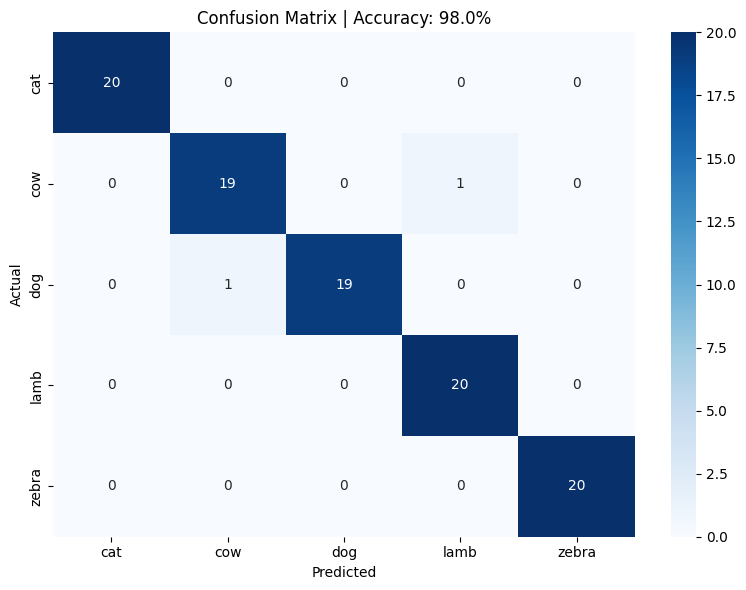


💾 Model saved!


In [9]:
import joblib
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

CLASSES = ['cat', 'cow', 'dog', 'lamb', 'zebra']

print("📂 Loading features...")
X_train, y_train, X_test, y_test = joblib.load(
    '/content/drive/MyDrive/new_animal_classifier/cnn_features.pkl')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\n🌲 Training Random Forest...")
model = RandomForestClassifier(
    n_estimators=500,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
acc    = accuracy_score(y_test, y_pred)
print(f"\n🎯 Test Accuracy: {acc * 100:.2f}%")

if acc >= 0.90:
    print("🎉 Target achieved! Above 90%!")
else:
    print("⚠️  Below 90% — needs tuning!")

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title(f'Confusion Matrix | Accuracy: {acc*100:.1f}%')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/new_animal_classifier/confusion_matrix.png')
plt.show()

joblib.dump(model,  '/content/drive/MyDrive/new_animal_classifier/rf_model.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/new_animal_classifier/scaler.pkl')
print("\n💾 Model saved!")


🔍 Testing cat image...


/tmp/ipykernel_4804/3006701862.py:41: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


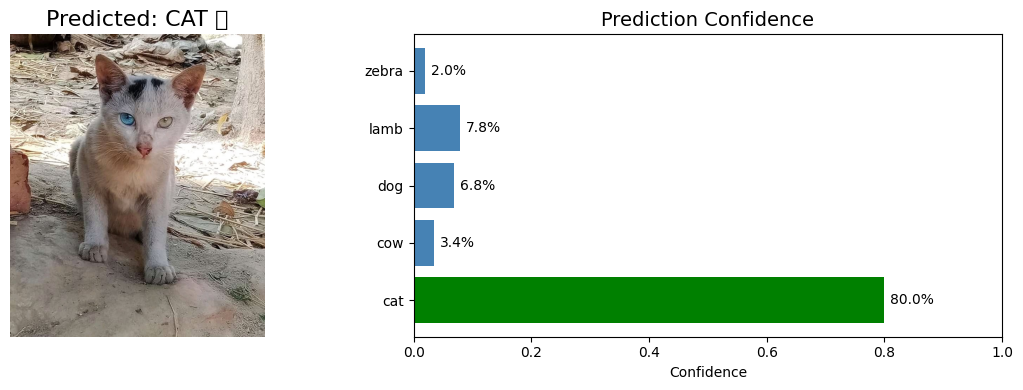

✅ Predicted: CAT (80.0% confidence)

🔍 Testing cow image...


/tmp/ipykernel_4804/3006701862.py:41: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


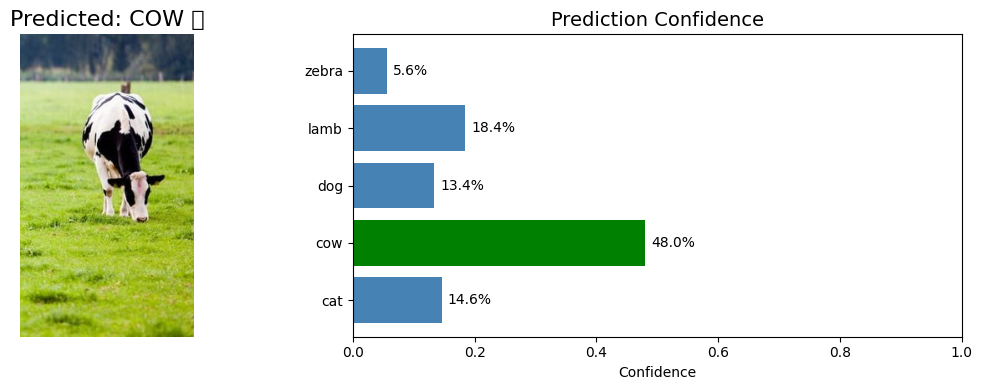

✅ Predicted: COW (48.0% confidence)

🔍 Testing dog image...


/tmp/ipykernel_4804/3006701862.py:41: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


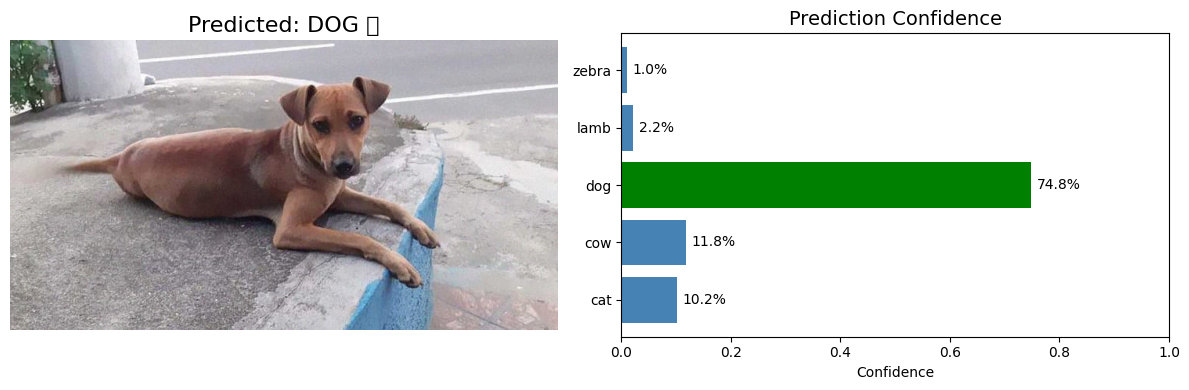

✅ Predicted: DOG (74.8% confidence)

🔍 Testing lamb image...


/tmp/ipykernel_4804/3006701862.py:41: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


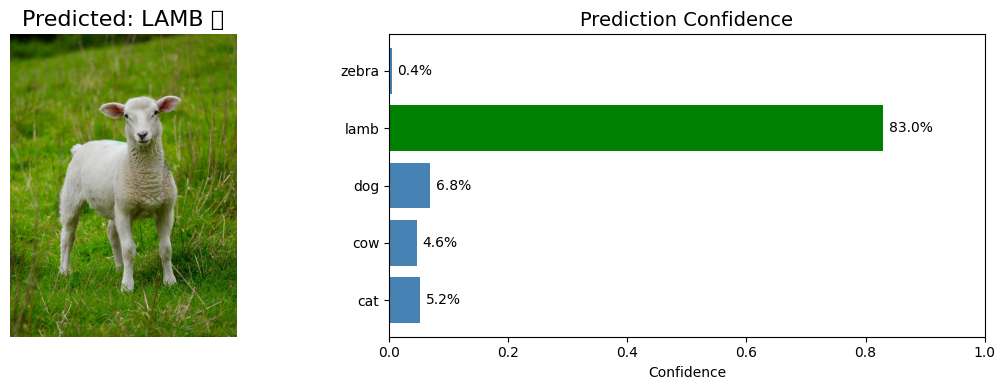

✅ Predicted: LAMB (83.0% confidence)

🔍 Testing zebra image...


/tmp/ipykernel_4804/3006701862.py:41: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


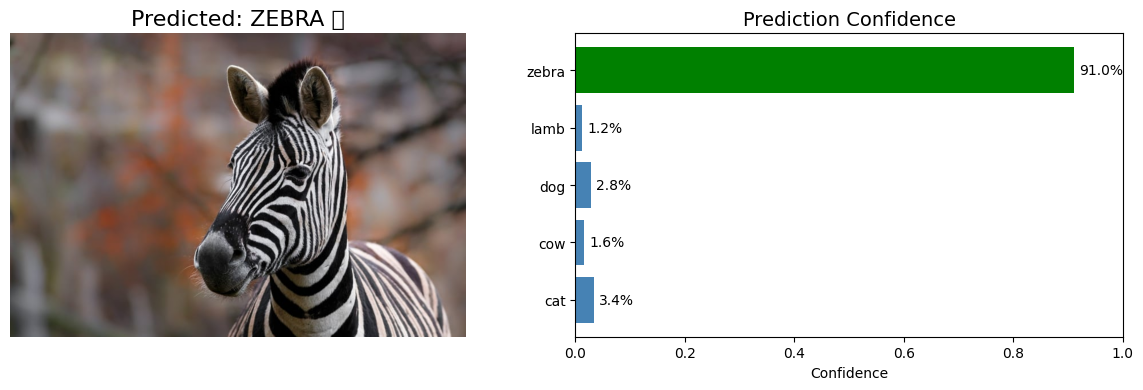

✅ Predicted: ZEBRA (91.0% confidence)


In [10]:
import cv2
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

CLASSES = ['cat', 'cow', 'dog', 'lamb', 'zebra']
model  = joblib.load('/content/drive/MyDrive/new_animal_classifier/rf_model.pkl')
scaler = joblib.load('/content/drive/MyDrive/new_animal_classifier/scaler.pkl')
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

def predict_and_show(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_input = preprocess_input(
        np.expand_dims(img_resized.astype('float32'), axis=0))

    features = base_model.predict(img_input, verbose=0)
    features_scaled = scaler.transform(features)
    pred  = model.predict(features_scaled)[0]
    proba = model.predict_proba(features_scaled)[0]

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title(f'Predicted: {CLASSES[pred].upper()} 🎯', fontsize=16)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    colors = ['green' if i == pred else 'steelblue' for i in range(len(CLASSES))]
    plt.barh(CLASSES, proba, color=colors)
    plt.xlabel('Confidence')
    plt.title('Prediction Confidence', fontsize=14)
    plt.xlim(0, 1)
    for i, v in enumerate(proba):
        plt.text(v + 0.01, i, f'{v*100:.1f}%', va='center')

    plt.tight_layout()
    plt.show()
    print(f"✅ Predicted: {CLASSES[pred].upper()} ({proba[pred]*100:.1f}% confidence)")

# Test one image from each class
test_folder = '/content/drive/MyDrive/new_animal_classifier/test'
for animal in CLASSES:
    folder = os.path.join(test_folder, animal)
    img_path = os.path.join(folder, os.listdir(folder)[0])
    print(f"\n🔍 Testing {animal} image...")
    predict_and_show(img_path)

🔍 Testing zebra image...


/tmp/ipykernel_4804/3006701862.py:41: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


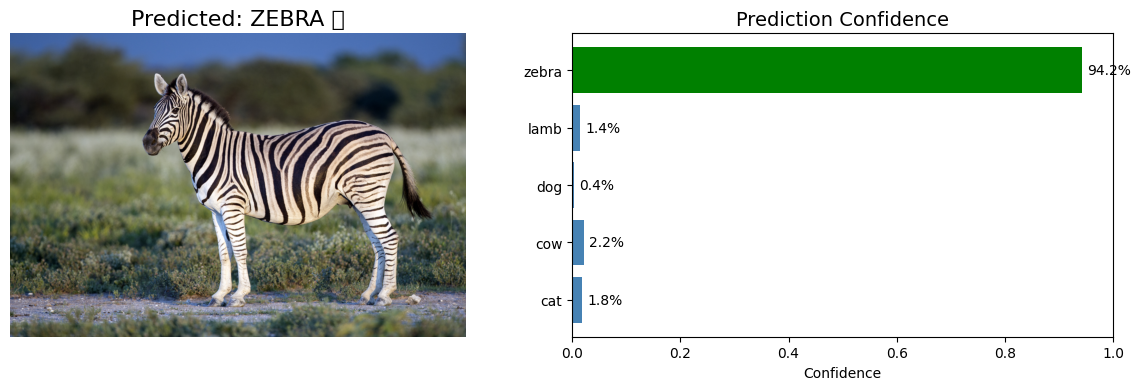

✅ Predicted: ZEBRA (94.2% confidence)


In [11]:
# Just run this cell anytime to test a new image!
import os

test_folder = '/content/drive/MyDrive/new_animal_classifier/test'

# Change this to any animal you want to test!
animal = 'zebra'  # ← change to: cat, cow, dog, lamb, zebra

folder = os.path.join(test_folder, animal)

# Change the number [0] to see different images [0],[1],[2]...
img_path = os.path.join(folder, os.listdir(folder)[2])

print(f"🔍 Testing {animal} image...")
predict_and_show(img_path)

🔍 Testing zebra image...


/tmp/ipykernel_4804/3006701862.py:41: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


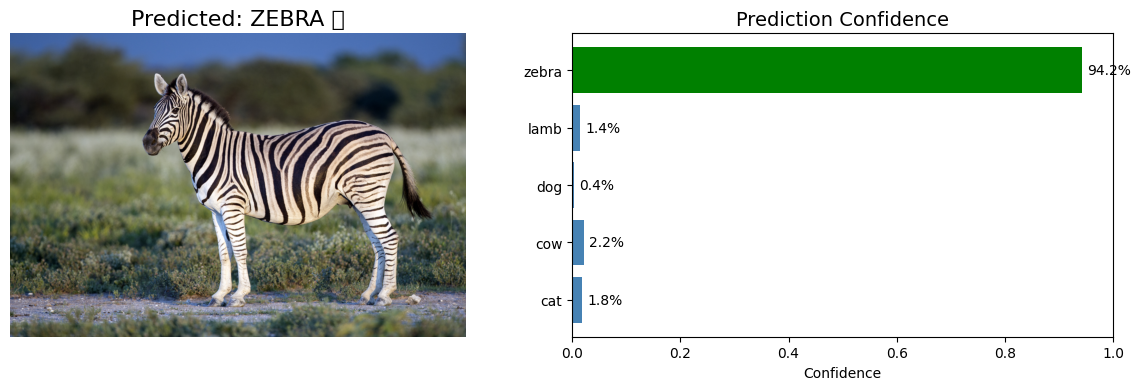

✅ Predicted: ZEBRA (94.2% confidence)


In [ ]:
# Just run this cell anytime to test a new image!
import os

test_folder = '/content/drive/MyDrive/new_animal_classifier/test'

# Change this to any animal you want to test!
animal = 'zebra'  # ← change to: cat, cow, dog, lamb, zebra

folder = os.path.join(test_folder, animal)

# Change the number [0] to see different images [0],[1],[2]...
img_path = os.path.join(folder, os.listdir(folder)[2])

print(f"🔍 Testing {animal} image...")
predict_and_show(img_path)

🔍 Testing zebra image...


/tmp/ipykernel_4804/3006701862.py:41: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


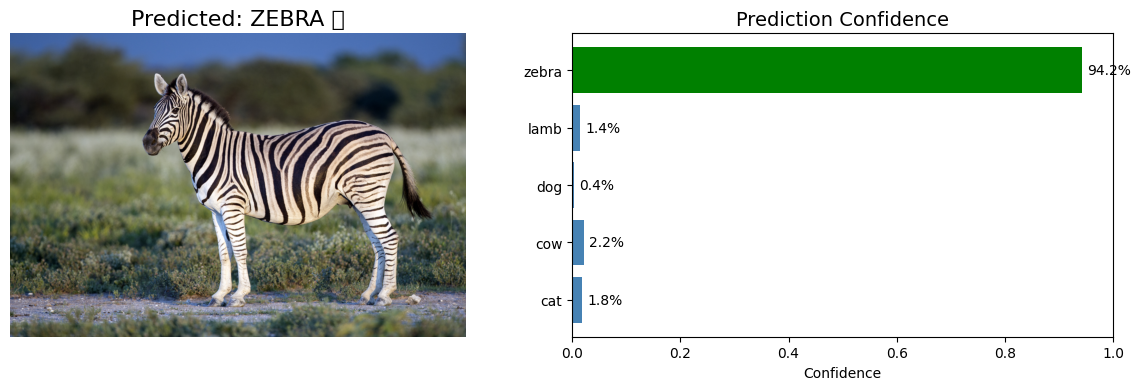

✅ Predicted: ZEBRA (94.2% confidence)


In [12]:
# Just run this cell anytime to test a new image!
import os

test_folder = '/content/drive/MyDrive/new_animal_classifier/test'

# Change this to any animal you want to test!
animal = 'zebra'  # ← change to: cat, cow, dog, lamb, zebra

folder = os.path.join(test_folder, animal)

# Change the number [0] to see different images [0],[1],[2]...
img_path = os.path.join(folder, os.listdir(folder)[2])

print(f"🔍 Testing {animal} image...")
predict_and_show(img_path)

🔍 Testing zebra image...


/tmp/ipykernel_4804/3006701862.py:41: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


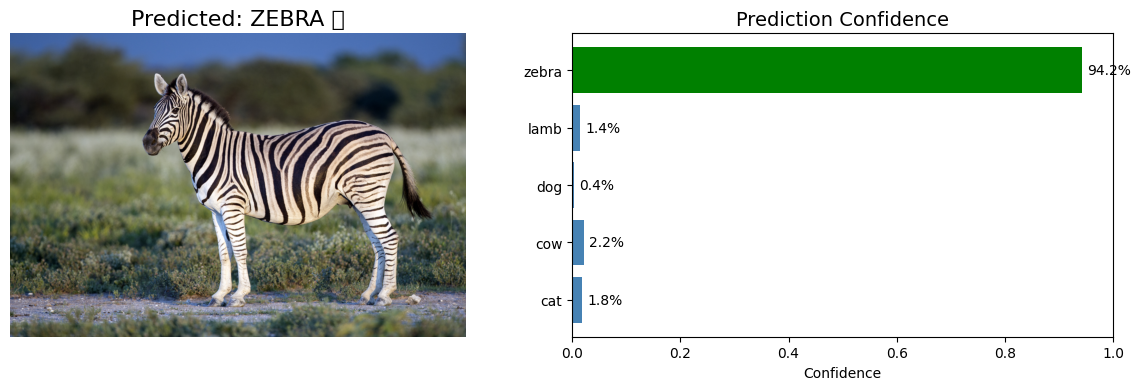

✅ Predicted: ZEBRA (94.2% confidence)


In [ ]:
# Just run this cell anytime to test a new image!
import os

test_folder = '/content/drive/MyDrive/new_animal_classifier/test'

# Change this to any animal you want to test!
animal = 'zebra'  # ← change to: cat, cow, dog, lamb, zebra

folder = os.path.join(test_folder, animal)

# Change the number [0] to see different images [0],[1],[2]...
img_path = os.path.join(folder, os.listdir(folder)[2])

print(f"🔍 Testing {animal} image...")
predict_and_show(img_path)